In [1]:
#MDP development
from math import e

MAX_CARS = 20
states = [(i, j) for i in range(MAX_CARS + 1)
                  for j in range(MAX_CARS + 1)]

jack_mdp = {state: {} for state in states}

gamma = 0.9

actions = list(range(-5, 6))

lambda_rent_1 = 3
lambda_rent_2 = 4
lambda_return_1 = 3
lambda_return_2 = 2

MAX_POISSON = 10
factorial = [1] * (MAX_POISSON + 1)
for i in range(1, MAX_POISSON + 1):
    factorial[i] = factorial[i - 1] * i

poisson = {}

lambdas = {lambda_rent_1, lambda_rent_2,
           lambda_return_1, lambda_return_2}

for lam in lambdas:
    probs = [0.0] * (MAX_POISSON + 1)
    exp_term = e ** (-lam)

    for k in range(MAX_POISSON):
        probs[k] = (lam ** k / factorial[k]) * exp_term

    probs[MAX_POISSON] = 1 - sum(probs[:MAX_POISSON])
    poisson[lam] = probs

def value_not_converged(v, new_v, tol):
    return max(abs(new_v[s] - v[s]) for s in v) > tol
 
p = poisson
cap = MAX_POISSON

for state in states:
    transitions = {}

    for action in actions:
        if action > state[0] or -action > state[1]:
            transitions[action] = [(0.0, state, 0.0)]
            continue

        a0 = state[0] - action
        a1 = state[1] + action

        if a0 < 0 or a1 < 0:
            continue

        a0 = min(a0, MAX_CARS)
        a1 = min(a1, MAX_CARS)

        tmp = {}

        for r1 in range(cap + 1):
            for r2 in range(cap + 1):
                for b1 in range(cap + 1):
                    for b2 in range(cap + 1):

                        realr1 = min(r1, a0)
                        realr2 = min(r2, a1)

                        next_state = (
                            max(0, min(a0 - realr1 + b1, MAX_CARS)),
                            max(0, min(a1 - realr2 + b2, MAX_CARS))
                        )

                        prob = (
                            p[lambda_rent_1][r1]
                            * p[lambda_rent_2][r2]
                            * p[lambda_return_1][b1]
                            * p[lambda_return_2][b2]
                        )

                        reward = -2 * abs(action) + 10 * (realr1 + realr2)

                        if next_state not in tmp:
                            tmp[next_state] = [0.0, 0.0]

                        tmp[next_state][0] += prob
                        tmp[next_state][1] += prob * reward

        transitions[action] = [
            (prob, s_next, rew / prob)
            for s_next, (prob, rew) in tmp.items()
            if prob > 0
        ]

    jack_mdp[state] = transitions

5


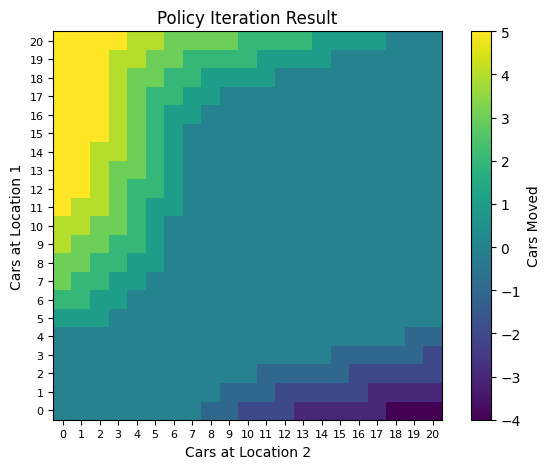

In [3]:
# Policy Iteration and Heatmap 
import numpy as np
import matplotlib.pyplot as plt

v = {s: 10.0 for s in states}
newv = {s: 0.0 for s in states}

oldpolicy = {s: 5 for s in states}
newpolicy = {s: 0 for s in states}

smol = 1e-4
it = 0

while newpolicy != oldpolicy:
    it += 1

    for s in states:
        v[s] = 10.0
        newv[s] = 0.0

    oldpolicy = newpolicy.copy()

    while value_not_converged(v, newv, smol):
        v = newv.copy()
        for state in states:
            val = 0.0
            for prob, next_state, reward in jack_mdp[state][newpolicy[state]]:
                val += prob * (reward + gamma * v[next_state])
            newv[state] = val

    for state in states:
        best_action = 0
        best_value = -float("inf")

        for action in actions:
            val = 0.0
            for prob, next_state, reward in jack_mdp[state][action]:
                val += prob * (reward + gamma * newv[next_state])

            if val > best_value:
                best_value = val
                best_action = action

        newpolicy[state] = best_action

print(it)

policy_grid = np.zeros((MAX_CARS + 1, MAX_CARS + 1))
for (i, j), action in newpolicy.items():
    policy_grid[i, j] = action

im = plt.imshow(
    policy_grid,
    origin="lower",
    cmap="viridis",
    interpolation="nearest"
)

plt.colorbar(im, label="Cars Moved")
plt.xlabel("Cars at Location 2")
plt.ylabel("Cars at Location 1")
plt.title("Policy Iteration Result")

plt.xticks(np.arange(0, MAX_CARS + 1, 1))
plt.yticks(np.arange(0, MAX_CARS + 1, 1))
plt.tick_params(axis="both", labelsize=8)

plt.tight_layout()
plt.show()
